# Tech Challenge Fase 3 - State of Data Brasil
## Notebook Completo de Evidencias: Consultas Analiticas e Graficos do Relatorio Executivo

Le as 10 tabelas Gold direto do S3 e reproduz **todo dado numerico e todo grafico citados no Relatorio Executivo**, organizado na mesma ordem das 7 perguntas de negocio do projeto. Cada bloco de codigo tem, logo acima, uma celula de markdown explicando o objetivo e a que secao/figura do relatorio ele corresponde.

**Tabelas Gold usadas neste notebook (10 de 10):**
`gold_estrutura_mercado` | `gold_perfis_profissionais` | `gold_diversidade` | `gold_diversidade_cargo` | `gold_adocao_tecnologia` | `gold_adocao_ia_prioridade` | `gold_adocao_ia_motivos` | `gold_regiao_senioridade_modelo` | `gold_desafios_gestor` | `gold_retencao`

**Status:** notebook executado de ponta a ponta no AWS Glue e conferido celula a celula contra o Relatorio Executivo - todos os 23 pontos de dado do relatorio tem evidencia rastreavel aqui, com os valores batendo exatamente com o texto e os graficos do relatorio.

### Setup: sessao interativa e leitura das tabelas Gold

In [1]:
%idle_timeout 30
%glue_version 5.1
%worker_type G.1X
%number_of_workers 2

import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job
from pyspark.sql import functions as F

sc = SparkContext.getOrCreate()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

BUCKET = "techchallenge-fase3-fiap-761328510173"
GOLD_BASE_PATH = f"s3://{BUCKET}/gold/"

def ler_gold(nome):
    return spark.read.parquet(f"{GOLD_BASE_PATH}{nome}/").toPandas()

print("Setup concluido.")

Welcome to the Glue Interactive Sessions Kernel
For more information on available magic commands, please type %help in any new cell.

Please view our Getting Started page to access the most up-to-date information on the Interactive Sessions kernel: https://docs.aws.amazon.com/glue/latest/dg/interactive-sessions.html
Installed kernel version: 1.0.10 
Current idle_timeout is None minutes.
idle_timeout has been set to 30 minutes.
Setting Glue version to: 5.1
Previous worker type: None
Setting new worker type to: G.1X
Previous number of workers: None
Setting new number of workers to: 2
Trying to create a Glue session for the kernel.
Session Type: glueetl
Worker Type: G.1X
Number of Workers: 2
Idle Timeout: 30
Session ID: 4c169dd3-65a7-4cba-b46c-ccf4202b163c
Applying the following default arguments:
--glue_kernel_version 1.0.10
--enable-glue-datacatalog true
Waiting for session 4c169dd3-65a7-4cba-b46c-ccf4202b163c to get into ready status...
Session 4c169dd3-65a7-4cba-b46c-ccf4202b163c has 

### Padrao visual: paleta, funcoes de grafico e utilitarios de tabela

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import re

COR_TEXTO = "#1F1F1F"
PALETA = ["#1F3864", "#2E75B6", "#9DC3E6", "#C00000", "#E06666"]
COR_DESTAQUE = PALETA[3]
COR_NEUTRA = PALETA[2]
CORES_LINHA_NEUTRAS = [PALETA[1], PALETA[2]]

plt.rcParams.update({
    "font.family": "sans-serif", "text.color": COR_TEXTO, "xtick.labelsize": 11,
    "axes.labelcolor": COR_TEXTO, "xtick.color": COR_TEXTO,
    "ytick.color": COR_TEXTO, "axes.edgecolor": COR_TEXTO,
})

def grafico_barras(labels, valores, titulo, subtitulo, idx_destaque=0, fmt="{:.0f}"):
    cores = [COR_DESTAQUE if i == idx_destaque else COR_NEUTRA for i in range(len(valores))]
    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.bar(labels, valores, color=cores, width=0.6)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.grid(False)
    for barra, valor in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height()*1.02,
                 fmt.format(valor), ha="center", va="bottom", fontsize=12,
                 color=COR_TEXTO, fontweight="bold")
    ax.set_title(titulo, fontsize=15, fontweight="bold", loc="left", pad=22, color=COR_TEXTO)
    fig.text(0.125, 0.90, subtitulo, fontsize=11, color="#4D4D4D")
    plt.xticks(rotation=15, ha="right")
    ax.margins(y=0.15)
    plt.tight_layout()

def grafico_linha(anos, series_dict, titulo, subtitulo, cor_destaque_serie=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    i_neutro = 0
    linhas = []
    for nome, valores in series_dict.items():
        if nome == cor_destaque_serie:
            cor, lw = COR_DESTAQUE, 3
        else:
            cor = CORES_LINHA_NEUTRAS[i_neutro % len(CORES_LINHA_NEUTRAS)]
            i_neutro += 1
            lw = 2
        ax.plot(anos, valores, color=cor, linewidth=lw, marker="o", markersize=6)
        linhas.append((nome, valores, cor))
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.grid(False)
    ax.set_xticks(anos)
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.07
    for nome, valores, cor in linhas:
        ax.text(anos[-1], valores[-1], f"  {nome}", va="center", fontsize=12, color=cor, fontweight="bold")
        for x, y in zip(anos, valores):
            ax.text(x, y + offset, f"{y:.1f}%", ha="center", fontsize=11, color=cor, fontweight="bold")
    ax.margins(x=0.2)
    ax.set_ylim(ymin - offset, ymax + offset * 3)
    ax.set_title(titulo, fontsize=15, fontweight="bold", loc="left", pad=22, color=COR_TEXTO)
    fig.text(0.125, 0.90, subtitulo, fontsize=11, color="#4D4D4D")
    plt.tight_layout()

def extrai_valor_faixa(s):
    """Extrai o piso numerico (em R$) de uma string de faixa salarial. Retorna -1 se nao aplicavel."""
    m = re.search(r"R\$\s*([\d\.]+)", str(s))
    return int(m.group(1).replace(".", "")) if m else -1

def mostra_tabela(df, titulo):
    """Imprime uma tabela pandas com titulo - usado para dados citados em texto/tabela no relatorio, sem grafico."""
    print(f"\n=== {titulo} ===")
    print(df.to_string(index=False))

def trunca(rotulos, tamanho=28):
    """Encurta rotulos longos (categorias com frase inteira) para caber no eixo do grafico."""
    return [r if len(r) <= tamanho else r[:tamanho-3] + "..." for r in rotulos]

TOTAIS_ANO = {2023: 5293, 2024: 5215, 2025: 3494}
TOTAL_GERAL = 14002
print("Funcoes de grafico e utilitarios definidos.")

Funcoes de grafico e utilitarios definidos.


## Pergunta 1: Como esta estruturado o mercado brasileiro de Dados?
*(Secao 3 do Relatorio Executivo)*

Duas evidencias: concentracao setorial (Figura 2) e porte de empresa (citado em texto, sem grafico no relatorio - mas com numero especifico de 41% que precisa de rastreabilidade).

### Concentracao setorial (Figura 2)

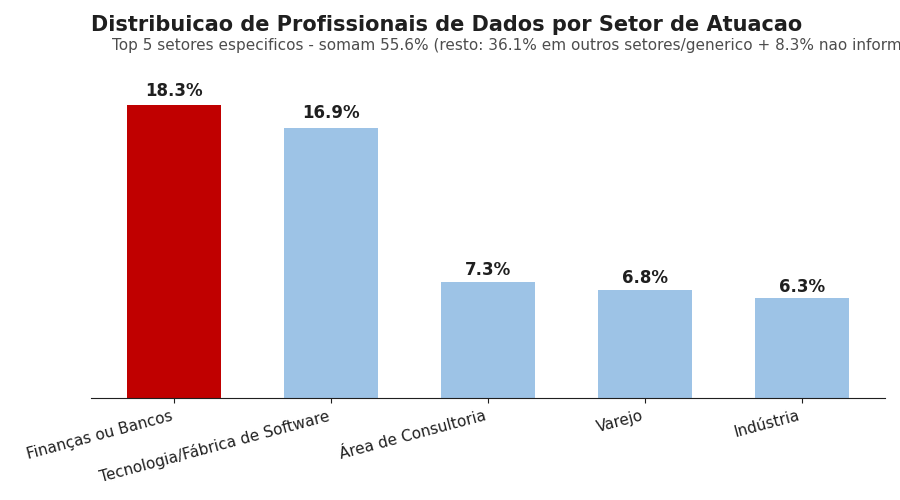

In [3]:
df1 = ler_gold("gold_estrutura_mercado")

# "Outra Opcao" e uma categoria generica (nao e um setor especifico) - excluida
# apenas da SELECAO do top-5, mantendo o denominador (TOTAL_GERAL) inalterado,
# entao os percentuais dos setores ja citados no relatorio nao mudam.
SETORES_GENERICOS = ["Não informado", "Outra Opção"]
candidatos_setor = df1[~df1["setor"].isin(SETORES_GENERICOS)]

top = (
    candidatos_setor.groupby("setor")["total_respondentes"].sum()
    .sort_values(ascending=False).head(5)
)
top_pct = (top / TOTAL_GERAL * 100).round(1)

soma_top5 = round(top_pct.sum(), 1)
pct_nao_informado = round(df1[df1["setor"] == "Não informado"]["total_respondentes"].sum() / TOTAL_GERAL * 100, 1)
pct_outros = round(100 - soma_top5 - pct_nao_informado, 1)

grafico_barras(
    top_pct.index.tolist(), top_pct.values.tolist(),
    "Distribuicao de Profissionais de Dados por Setor de Atuacao",
    f"Top 5 setores especificos - somam {soma_top5}% (resto: {pct_outros}% em outros setores/generico + {pct_nao_informado}% nao informado)",
    fmt="{:.1f}%"
)
%matplot plt

### Porte de empresa (citado no texto da Secao 3: "41% em empresas acima de 3.000 funcionarios")

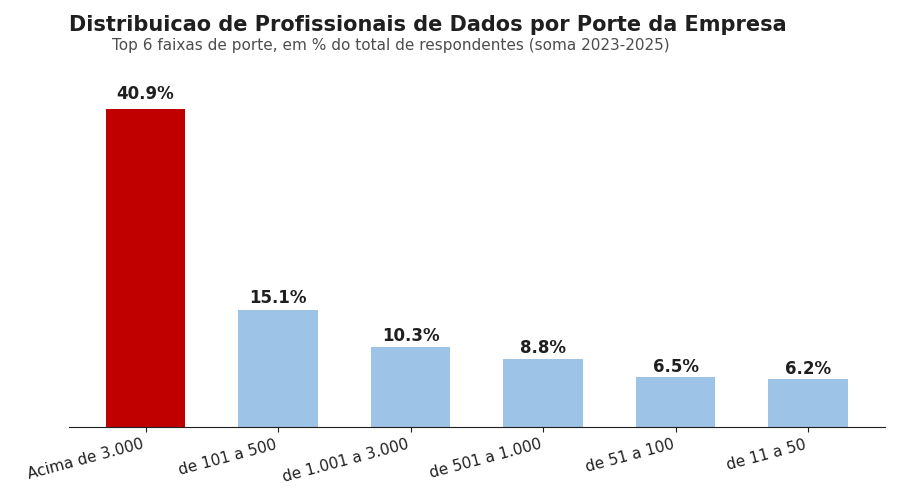

In [4]:
porte = (
    df1[df1["num_funcionarios"] != "Não informado"]
    .groupby("num_funcionarios")["total_respondentes"].sum()
    .sort_values(ascending=False).head(6)
)
porte_pct = (porte / TOTAL_GERAL * 100).round(1)

grafico_barras(
    porte_pct.index.tolist(), porte_pct.values.tolist(),
    "Distribuicao de Profissionais de Dados por Porte da Empresa",
    "Top 6 faixas de porte, em % do total de respondentes (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

## Pergunta 2: Quais perfis profissionais sao mais valorizados pelo mercado?
*(Secao 4 do Relatorio Executivo)*

**Nota:** o cargo "Engenheiro de Dados" tem redacao levemente diferente entre anos na pesquisa original; harmonizamos para nao duplicar a contagem.

### Cargo mais comum (Figura 3)

In [ ]:
df2 = ler_gold("gold_perfis_profissionais")
df2["cargo_norm"] = df2["cargo"].replace({
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados/Data Engineer/Data Architect",
})
df2_aplicavel = df2[df2["cargo_norm"] != "Não aplicável"]
total_aplicavel = df2_aplicavel["total_respondentes"].sum()

# "Outra opcao" e uma categoria generica (nao e um cargo especifico) - excluida
# apenas da SELECAO do top-5, mantendo o denominador (total_aplicavel) inalterado,
# entao os percentuais ja citados no relatorio nao mudam.
CARGOS_GENERICOS = ["Outra opção", "Outra Opção"]
candidatos_cargo = df2_aplicavel[~df2_aplicavel["cargo_norm"].isin(CARGOS_GENERICOS)]

top_cargo = (
    candidatos_cargo.groupby("cargo_norm")["total_respondentes"].sum()
    .sort_values(ascending=False).head(5)
)
top_cargo_pct = (top_cargo / total_aplicavel * 100).round(1)

# Nomes curtos para exibicao - mapeamento manual (mais limpo que truncar com "...")
NOMES_CURTOS_CARGO = {
    "Analista de Dados/Data Analyst": "Analista de Dados",
    "Cientista de Dados/Data Scientist": "Cientista de Dados",
    "Engenheiro de Dados/Data Engineer/Data Architect": "Engenheiro de Dados",
    "Analista de BI/BI Analyst": "Analista de BI",
    "Analista de Negócios/Business Analyst": "Analista de Negócios",
}
labels_cargo = [NOMES_CURTOS_CARGO.get(c, c) for c in top_cargo_pct.index.tolist()]

grafico_barras(
    labels_cargo, top_cargo_pct.values.tolist(),
    "Distribuicao de Profissionais por Cargo Ocupado",
    "Top 5 cargos especificos, entre respondentes com cargo aplicavel (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

### Progressao salarial por senioridade (Tabela da Secao 4.1)

In [6]:
ordem_senioridade = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]

df2_sen = df2[df2["senioridade"] != "Não aplicável"].copy()
df2_sen["valor_faixa"] = df2_sen["faixa_salarial"].apply(extrai_valor_faixa)

linhas = []
for sen in ordem_senioridade:
    sub = df2_sen[df2_sen["senioridade"] == sen]
    total_sen = sub["total_respondentes"].sum()
    faixa_comum = sub.groupby("faixa_salarial")["total_respondentes"].sum().idxmax()
    faixa_alta = sub[sub["valor_faixa"] >= 12000]["total_respondentes"].sum()
    linhas.append({
        "Senioridade": sen,
        "Faixa salarial mais comum": faixa_comum,
        "% em faixa alta (>=R$12.000)": round(faixa_alta / total_sen * 100, 1),
    })

tabela_senioridade = pd.DataFrame(linhas)
mostra_tabela(tabela_senioridade, "Progressao Salarial por Senioridade (Secao 4.1 do relatorio)")


=== Progressao Salarial por Senioridade (Secao 4.1 do relatorio) ===
        Senioridade        Faixa salarial mais comum  % em faixa alta (>=R$12.000)
             Júnior   de R$ 4.001/mês a R$ 6.000/mês                           1.2
              Pleno  de R$ 8.001/mês a R$ 12.000/mês                           9.4
             Sênior  de R$ 8.001/mês a R$ 12.000/mês                          53.1
Especialista/Staff+ de R$ 12.001/mês a R$ 16.000/mês                          83.7


## Pergunta 3: Qual o cenario de diversidade de genero nas carreiras de dados?
*(Secao 5 do Relatorio Executivo)*

### Evolucao da distribuicao de genero 2023-2025 (Figura 4)

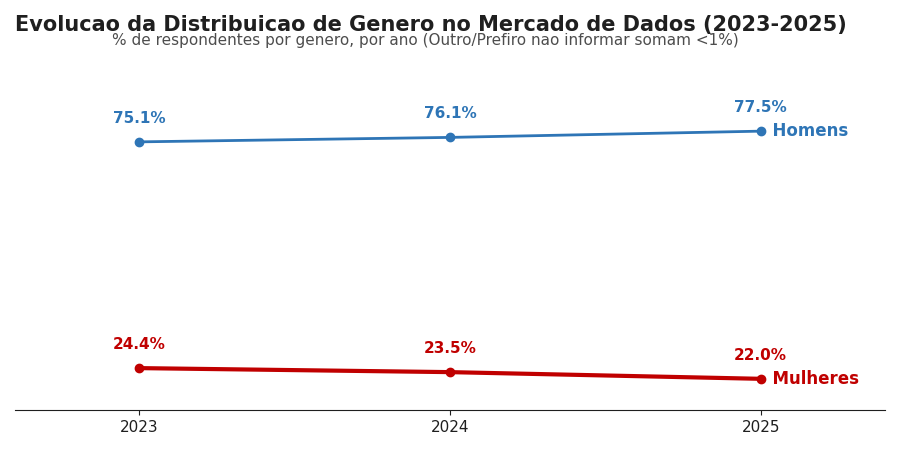

In [7]:
df3 = ler_gold("gold_diversidade")
genero_ano = df3.groupby(["ano_pesquisa","genero"])["total_respondentes"].sum().unstack()
pct = genero_ano.div(genero_ano.sum(axis=1), axis=0) * 100
grafico_linha(
    [2023, 2024, 2025],
    {"Homens": pct["Masculino"].round(1).tolist(), "Mulheres": pct["Feminino"].round(1).tolist()},
    "Evolucao da Distribuicao de Genero no Mercado de Dados (2023-2025)",
    "% de respondentes por genero, por ano (Outro/Prefiro nao informar somam <1%)",
    cor_destaque_serie="Mulheres"
)
%matplot plt

### Gap salarial geral por genero (citado na Secao 5: "38,9% x 28,6%")

In [8]:
df3["valor_faixa"] = df3["faixa_salarial"].apply(extrai_valor_faixa)
df3_validos = df3[df3["valor_faixa"] >= 0]

linhas = []
for g in ["Masculino", "Feminino"]:
    sub = df3_validos[df3_validos["genero"] == g]
    total = sub["total_respondentes"].sum()
    alta = sub[sub["valor_faixa"] >= 12000]["total_respondentes"].sum()
    linhas.append({"Genero": g, "% em faixa alta (>=R$12.000)": round(alta / total * 100, 1)})

tabela_genero = pd.DataFrame(linhas)
mostra_tabela(tabela_genero, "Gap Salarial Geral por Genero (Secao 5 do relatorio)")
gap_genero = round(tabela_genero.iloc[0, 1] - tabela_genero.iloc[1, 1], 1)
print(f"Gap (Homens - Mulheres): {gap_genero} p.p.")


=== Gap Salarial Geral por Genero (Secao 5 do relatorio) ===
   Genero  % em faixa alta (>=R$12.000)
Masculino                          38.9
 Feminino                          28.6
Gap (Homens - Mulheres): 10.3 p.p.


### Teto de vidro: representatividade feminina por senioridade (Figura 5)

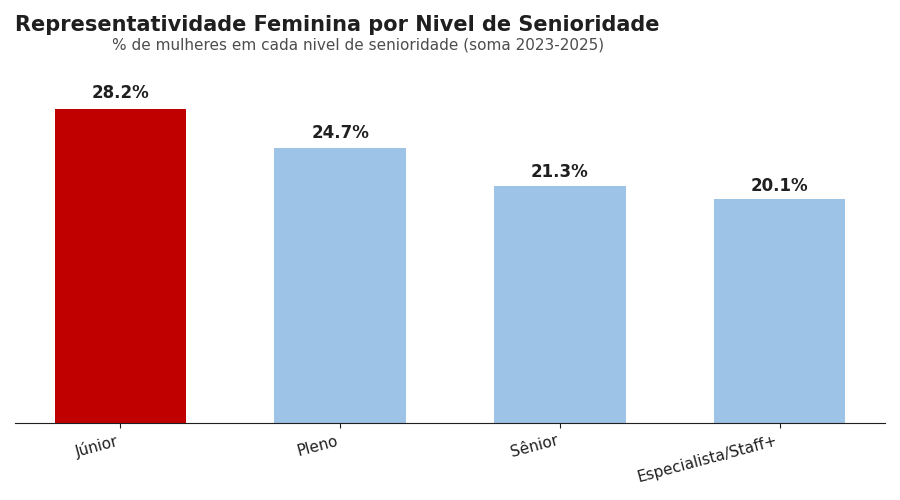

In [9]:
df3_sen = df3[df3["senioridade"] != "Não aplicável"]
genero_sen = df3_sen.groupby(["senioridade", "genero"])["total_respondentes"].sum().unstack()
pct_fem_sen = (genero_sen["Feminino"] / genero_sen.sum(axis=1) * 100).round(1)
pct_fem_sen = pct_fem_sen.reindex(ordem_senioridade)

grafico_barras(
    ordem_senioridade, pct_fem_sen.values.tolist(),
    "Representatividade Feminina por Nivel de Senioridade",
    "% de mulheres em cada nivel de senioridade (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

### Gap salarial por senioridade e genero (Tabela da Secao 5.2)

In [10]:
df3_sen_valor = df3_sen.copy()
df3_sen_valor["valor_faixa"] = df3_sen_valor["faixa_salarial"].apply(extrai_valor_faixa)
df3_sen_valor = df3_sen_valor[df3_sen_valor["valor_faixa"] >= 0]

linhas = []
for sen in ordem_senioridade:
    sub = df3_sen_valor[df3_sen_valor["senioridade"] == sen]
    pcts = {}
    for g in ["Masculino", "Feminino"]:
        subg = sub[sub["genero"] == g]
        total = subg["total_respondentes"].sum()
        alta = subg[subg["valor_faixa"] >= 12000]["total_respondentes"].sum()
        pcts[g] = round(alta / total * 100, 1) if total > 0 else None
    gap = round(pcts["Masculino"] - pcts["Feminino"], 1) if None not in pcts.values() else None
    linhas.append({
        "Senioridade": sen,
        "% Homens faixa alta": pcts["Masculino"],
        "% Mulheres faixa alta": pcts["Feminino"],
        "Gap (p.p.)": gap,
    })

tabela_gap_sen = pd.DataFrame(linhas)
mostra_tabela(tabela_gap_sen, "Gap Salarial por Senioridade e Genero (Secao 5.2 do relatorio)")


=== Gap Salarial por Senioridade e Genero (Secao 5.2 do relatorio) ===
        Senioridade  % Homens faixa alta  % Mulheres faixa alta  Gap (p.p.)
             Júnior                  1.2                    0.9         0.3
              Pleno                 10.1                    7.4         2.7
             Sênior                 55.5                   44.5        11.0
Especialista/Staff+                 83.3                   84.3        -1.0


### % de mulheres por cargo (Tabela da Secao 5.3)

**Pre-requisito:** rodem antes, no notebook de modelagem Silver->Gold, a celula que cria a tabela `gold_diversidade_cargo` (ver notebook `adicoes_silver_gold_bi_e_cargo.ipynb`). Sem isso, a celula abaixo falha com "path does not exist" no S3.

In [11]:
df3c = ler_gold("gold_diversidade_cargo")

# Mesma harmonizacao aplicada na celula de "Cargo mais comum" (Pergunta 2),
# necessaria aqui tambem para nao fragmentar a contagem por variacao de nome
CARGO_HARMONIZACAO = {
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados/Data Engineer/Data Architect",
}
df3c["cargo_norm"] = df3c["cargo"].replace(CARGO_HARMONIZACAO)

# "Outra Opcao" e uma categoria generica (nao e um cargo especifico) e nao
# agrega valor numa tabela sobre representatividade POR cargo - excluida do
# ranking junto com "Nao aplicavel", para que o top-5 mostre apenas cargos reais.
CARGOS_EXCLUIDOS = ["Não aplicável", "Outra Opção"]
df3c_validos = df3c[~df3c["cargo_norm"].isin(CARGOS_EXCLUIDOS)]

total_por_cargo = df3c_validos.groupby("cargo_norm")["total_respondentes"].sum().sort_values(ascending=False)
top5_cargos = total_por_cargo.head(5).index.tolist()

linhas = []
for cargo in top5_cargos:
    sub = df3c_validos[df3c_validos["cargo_norm"] == cargo]
    total = sub["total_respondentes"].sum()
    mulheres = sub[sub["genero"] == "Feminino"]["total_respondentes"].sum()
    linhas.append({
        "Cargo": cargo,
        "% Mulheres": round(mulheres / total * 100, 1),
        "Base (n)": int(total),
    })

tabela_cargo_genero = pd.DataFrame(linhas).sort_values("% Mulheres")
mostra_tabela(tabela_cargo_genero, "Representatividade Feminina por Cargo (Secao 5.3 do relatorio)")


=== Representatividade Feminina por Cargo (Secao 5.3 do relatorio) ===
                                           Cargo  % Mulheres  Base (n)
Engenheiro de Dados/Data Engineer/Data Architect        16.7      1698
                       Analista de BI/BI Analyst        22.5      1117
               Cientista de Dados/Data Scientist        22.8      1797
                  Analista de Dados/Data Analyst        28.1      2463
           Analista de Negócios/Business Analyst        32.1       520


## Pergunta 4: Quais tecnologias apresentam maior adocao entre os profissionais?
*(Secao 6 do Relatorio Executivo)*

Tres frentes no relatorio: linguagens de programacao, provedores de nuvem e ferramentas de BI.

### Linguagens de programacao (Figura 6)

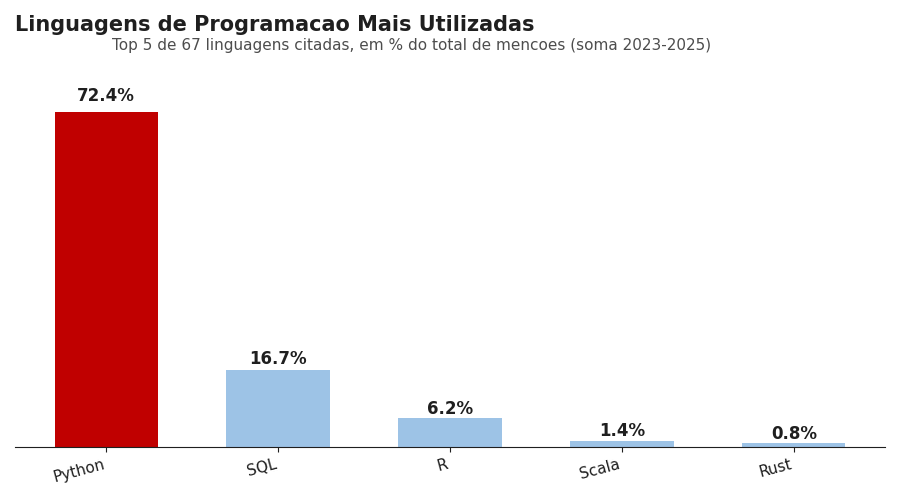

In [12]:
df4 = ler_gold("gold_adocao_tecnologia")
ling = df4[df4["categoria"] == "linguagem_preferida"].copy()
rows = []
for _, r in ling.iterrows():
    for item in str(r["item"]).split(","):
        item = item.strip()
        if item and item not in ("Não informado", "Nenhuma das opções"):
            rows.append({"linguagem": item, "total": r["total_respondentes"]})
exploded = pd.DataFrame(rows)
total_mencoes_ling = exploded["total"].sum()
top_ling = exploded.groupby("linguagem")["total"].sum().sort_values(ascending=False).head(5)
top_ling_pct = (top_ling / total_mencoes_ling * 100).round(1)
grafico_barras(
    top_ling_pct.index.tolist(), top_ling_pct.values.tolist(),
    "Linguagens de Programacao Mais Utilizadas",
    "Top 5 de 67 linguagens citadas, em % do total de mencoes (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

### Evolucao de provedores de nuvem (Figura 7)

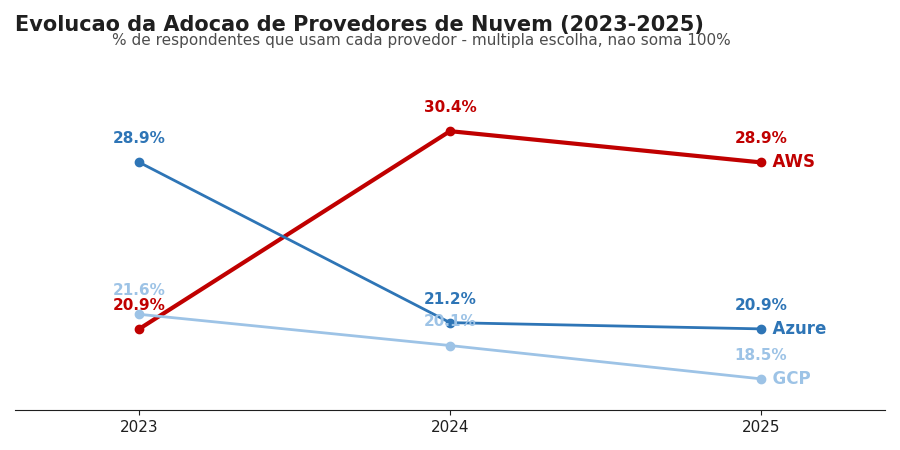

In [13]:
cloud = df4[df4["categoria"] == "cloud_usada"]
cloud_top3 = cloud[cloud["item"].isin([
    "Amazon Web Services (AWS)", "Azure (Microsoft)", "Google Cloud (GCP)"
])]
piv = cloud_top3.pivot_table(index="ano_pesquisa", columns="item", values="total_respondentes")
for ano in piv.index:
    piv.loc[ano] = piv.loc[ano] / TOTAIS_ANO[ano] * 100
grafico_linha(
    [2023, 2024, 2025],
    {
        "AWS": piv["Amazon Web Services (AWS)"].round(1).tolist(),
        "Azure": piv["Azure (Microsoft)"].round(1).tolist(),
        "GCP": piv["Google Cloud (GCP)"].round(1).tolist(),
    },
    "Evolucao da Adocao de Provedores de Nuvem (2023-2025)",
    "% de respondentes que usam cada provedor - multipla escolha, nao soma 100%",
    cor_destaque_serie="AWS"
)
%matplot plt

### Ferramentas de Business Intelligence (Figura 8)

**Pre-requisito:** rodem antes, no notebook `notebook-silver-to-gold`, a celula que adiciona a categoria `ferramenta_bi_preferida` na `gold_adocao_tecnologia`, usando a coluna `bi_preferida` que ja existe na Silver "wide" (mesmo padrao ja usado para `linguagem_preferida`). O relatorio (Figura 8) recorta apenas o ano de 2025 e exclui quem nao respondeu - reproduzimos o mesmo recorte aqui.


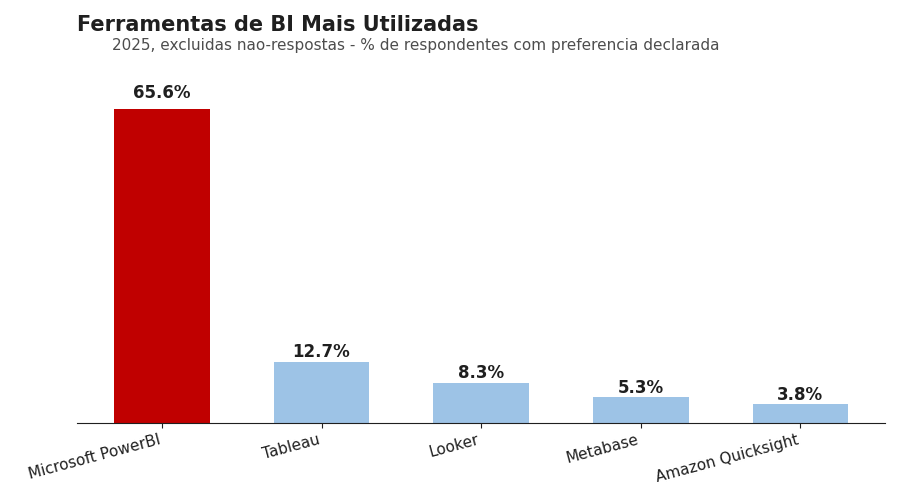

In [14]:
bi = df4[(df4["categoria"] == "ferramenta_bi_preferida") & (df4["ano_pesquisa"] == 2025)].copy()

NAO_RESPOSTA_BI = ["Não informado", "Não tenho preferência / Não sei opinar"]
bi_validas = bi[~bi["item"].isin(NAO_RESPOSTA_BI)]

total_bi_2025 = bi_validas["total_respondentes"].sum()
top_bi = bi_validas.groupby("item")["total_respondentes"].sum().sort_values(ascending=False).head(5)
top_bi_pct = (top_bi / total_bi_2025 * 100).round(1)
labels_bi = trunca(top_bi_pct.index.tolist(), tamanho=22)

grafico_barras(
    labels_bi, top_bi_pct.values.tolist(),
    "Ferramentas de BI Mais Utilizadas",
    "2025, excluidas nao-respostas - % de respondentes com preferencia declarada",
    fmt="{:.1f}%"
)
%matplot plt

## Pergunta 5: Qual o indice de adocao de Inteligencia Artificial e seu impacto?
*(Secao 7 do Relatorio Executivo)*

**Nota:** a pergunta original de uso individual tem 3 respostas possiveis (usa, nao usa, nao informado). Exibimos as 3 para que os percentuais somem 100% em cada ano.

### Evolucao do uso individual de IA generativa (Figura 9)

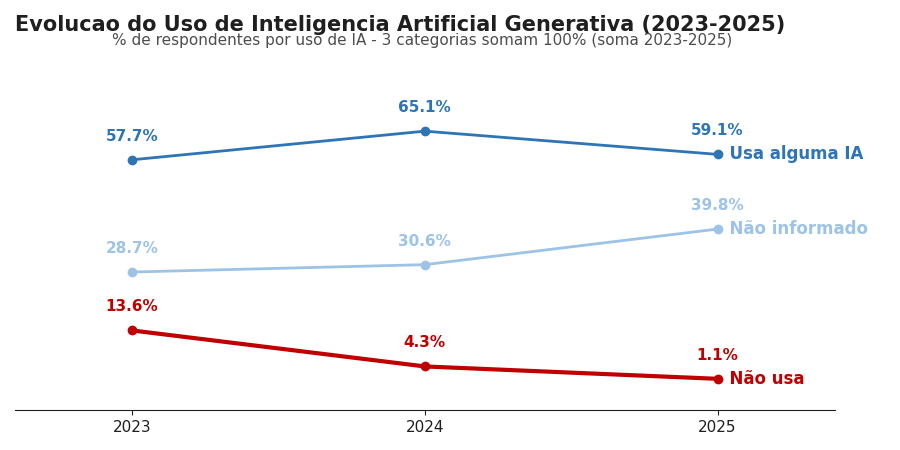

In [15]:
df5 = ler_gold("gold_adocao_ia_prioridade")

def classifica_uso(v):
    if v == "Não informado":
        return "Não informado"
    if v.startswith("Não utilizo nenhum tipo") and "," not in v:
        return "Não utilizo"
    return "Utiliza"

df5["cat_uso"] = df5["usa_ia_generativa"].apply(classifica_uso)
resumo_uso = df5.groupby(["ano_pesquisa","cat_uso"])["total_respondentes"].sum().unstack().fillna(0).astype(float)
for ano in resumo_uso.index:
    resumo_uso.loc[ano] = resumo_uso.loc[ano] / TOTAIS_ANO[ano] * 100

grafico_linha(
    [2023, 2024, 2025],
    {
        "Usa alguma IA": resumo_uso["Utiliza"].round(1).tolist(),
        "Não usa": resumo_uso["Não utilizo"].round(1).tolist(),
        "Não informado": resumo_uso["Não informado"].round(1).tolist(),
    },
    "Evolucao do Uso de Inteligencia Artificial Generativa (2023-2025)",
    "% de respondentes por uso de IA - 3 categorias somam 100% (soma 2023-2025)",
    cor_destaque_serie="Não usa"
)
%matplot plt

### Descompasso estrategico: prioridade corporativa de IA (citado na Secao 7: "entre 6% e 11%")

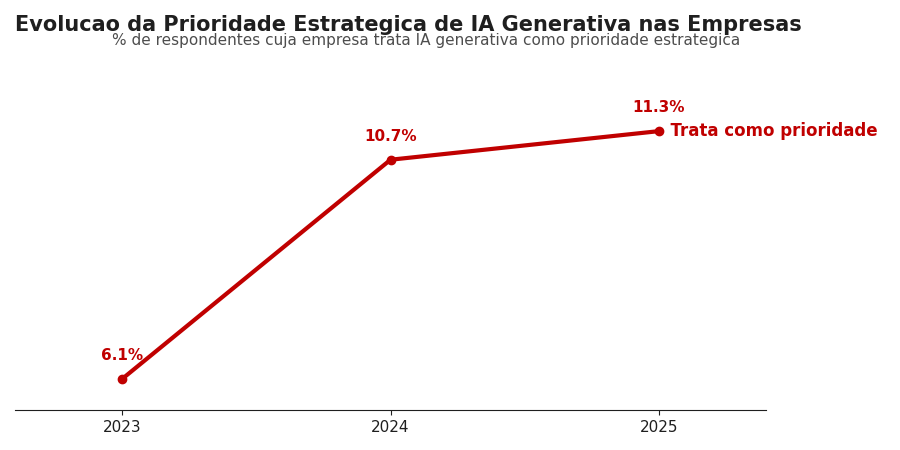

In [16]:
def classifica_prioridade(v):
    if str(v).startswith("Sim,"):
        return "E prioridade"
    if v == "Não sei opinar sobre esse assunto.":
        return "Nao sabe opinar"
    if v == "Não informado":
        return "Nao informado"
    return "Nao e prioridade"

df5["cat_prioridade"] = df5["ia_prioridade"].apply(classifica_prioridade)
resumo_prior = df5.groupby(["ano_pesquisa", "cat_prioridade"])["total_respondentes"].sum().unstack().fillna(0)
for ano in resumo_prior.index:
    resumo_prior.loc[ano] = resumo_prior.loc[ano] / TOTAIS_ANO[ano] * 100

grafico_linha(
    [2023, 2024, 2025],
    {"Trata como prioridade": resumo_prior["E prioridade"].round(1).tolist()},
    "Evolucao da Prioridade Estrategica de IA Generativa nas Empresas",
    "% de respondentes cuja empresa trata IA generativa como prioridade estrategica",
    cor_destaque_serie="Trata como prioridade"
)
%matplot plt

### Principais motivos para nao adotar IA generativa (citado na Secao 7: "principal barreira a adocao corporativa")

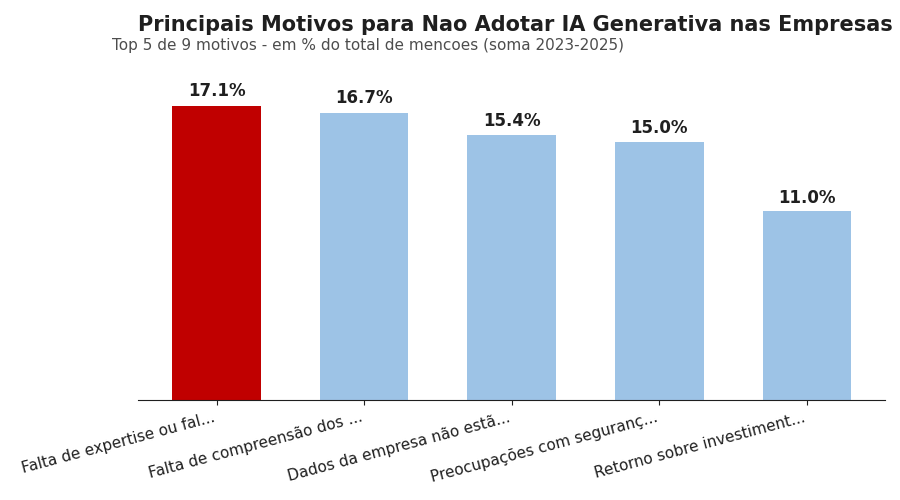

In [17]:
df5c = ler_gold("gold_adocao_ia_motivos")
total_motivos = df5c["total_mencoes"].sum()
top_motivos = df5c.groupby("item")["total_mencoes"].sum().sort_values(ascending=False).head(5)
top_motivos_pct = (top_motivos / total_motivos * 100).round(1)

# Usamos o texto real da categoria (truncado) em vez de rotulos abreviados fixos,
# pois nao temos os totais reais para confirmar a ordem do ranking fora do ambiente AWS.
labels_motivos = trunca(top_motivos_pct.index.tolist())

grafico_barras(
    labels_motivos, top_motivos_pct.values.tolist(),
    "Principais Motivos para Nao Adotar IA Generativa nas Empresas",
    "Top 5 de 9 motivos - em % do total de mencoes (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

## Pergunta 6: Existem diferencas relevantes entre regioes, senioridades ou modelos de trabalho?
*(Secao 8 do Relatorio Executivo)*

### Salario elevado por regiao (Figura 10)

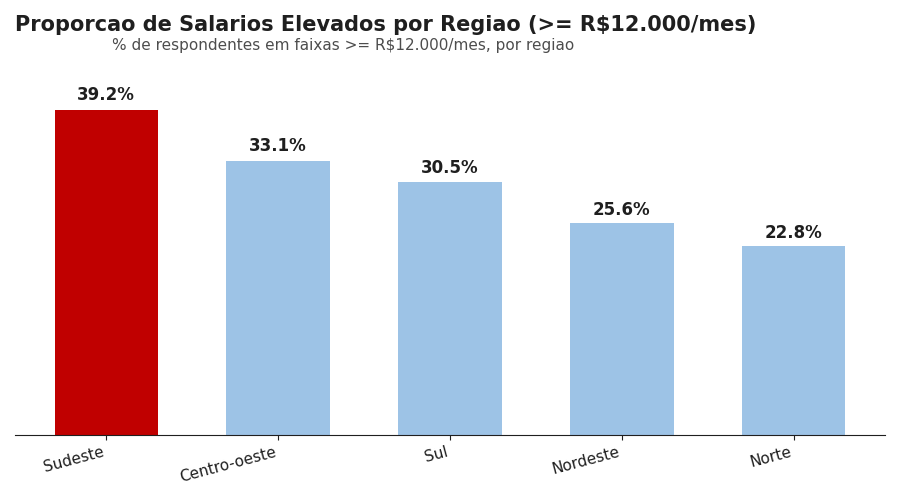

In [18]:
df6 = ler_gold("gold_regiao_senioridade_modelo")
df6["valor_faixa"] = df6["faixa_salarial"].apply(extrai_valor_faixa)
sub_regiao = df6[df6["valor_faixa"] >= 0]

resultados_regiao = {}
for reg in ["Sudeste", "Centro-oeste", "Sul", "Nordeste", "Norte"]:
    r = sub_regiao[sub_regiao["regiao"] == reg]
    total = r["total_respondentes"].sum()
    alta = r[r["valor_faixa"] >= 12000]["total_respondentes"].sum()
    resultados_regiao[reg] = alta / total * 100

grafico_barras(
    list(resultados_regiao.keys()), [round(v, 1) for v in resultados_regiao.values()],
    "Proporcao de Salarios Elevados por Regiao (>= R$12.000/mes)",
    "% de respondentes em faixas >= R$12.000/mes, por regiao",
    fmt="{:.1f}%"
)
%matplot plt

### Concentracao de profissionais por regiao (citado na Secao 8: "60,5% no Sudeste")

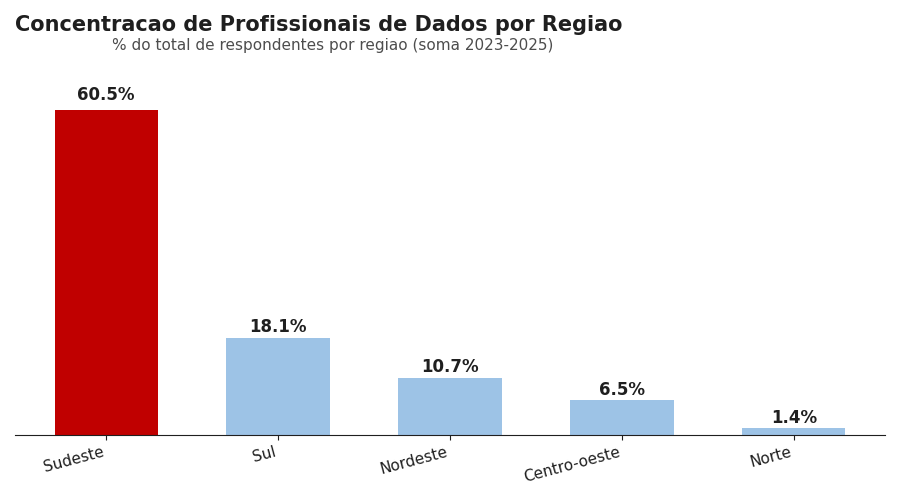

In [19]:
regiao_dist = df6[df6["regiao"] != "Não informado"].groupby("regiao")["total_respondentes"].sum()
regiao_dist_pct = (regiao_dist / TOTAL_GERAL * 100).round(1).sort_values(ascending=False)

grafico_barras(
    regiao_dist_pct.index.tolist(), regiao_dist_pct.values.tolist(),
    "Concentracao de Profissionais de Dados por Regiao",
    "% do total de respondentes por regiao (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

### Composicao de senioridade por regiao (Secao 8.1: "Sudeste 43,3% x Norte 31,4%")

In [20]:
df6_sen = df6[df6["senioridade"] != "Não aplicável"]
linhas = []
for reg in ["Sudeste", "Centro-oeste", "Sul", "Nordeste", "Norte"]:
    sub = df6_sen[df6_sen["regiao"] == reg]
    total = sub["total_respondentes"].sum()
    sr_esp = sub[sub["senioridade"].isin(["Sênior", "Especialista/Staff+"])]["total_respondentes"].sum()
    linhas.append({"Regiao": reg, "% Senior + Especialista": round(sr_esp / total * 100, 1)})

tabela_sen_regiao = pd.DataFrame(linhas).sort_values("% Senior + Especialista", ascending=False)
mostra_tabela(tabela_sen_regiao, "Composicao de Senioridade por Regiao (Secao 8.1 do relatorio)")


=== Composicao de Senioridade por Regiao (Secao 8.1 do relatorio) ===
      Regiao  % Senior + Especialista
     Sudeste                     43.4
         Sul                     40.1
Centro-oeste                     37.3
    Nordeste                     32.8
       Norte                     31.4


### Salario elevado por modelo de trabalho (Figura 11)

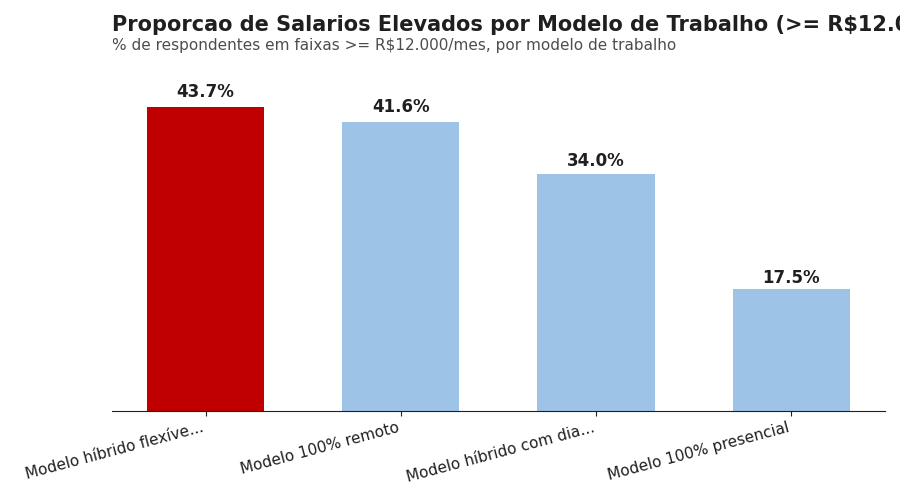

In [21]:
df6_modelo = df6[(df6["valor_faixa"] >= 0) & (df6["modelo_trabalho"] != "Não informado")]
resultados_modelo = {}
for modelo in df6_modelo["modelo_trabalho"].unique():
    sub = df6_modelo[df6_modelo["modelo_trabalho"] == modelo]
    total = sub["total_respondentes"].sum()
    alta = sub[sub["valor_faixa"] >= 12000]["total_respondentes"].sum()
    resultados_modelo[modelo] = round(alta / total * 100, 1)

modelo_series = pd.Series(resultados_modelo).sort_values(ascending=False)
labels_modelo = trunca(modelo_series.index.tolist(), tamanho=25)

grafico_barras(
    labels_modelo, modelo_series.values.tolist(),
    "Proporcao de Salarios Elevados por Modelo de Trabalho (>= R$12.000/mes)",
    "% de respondentes em faixas >= R$12.000/mes, por modelo de trabalho",
    fmt="{:.1f}%"
)
%matplot plt

### Modelo de trabalho mais comum (citado na Secao 8.1: "41% remoto")

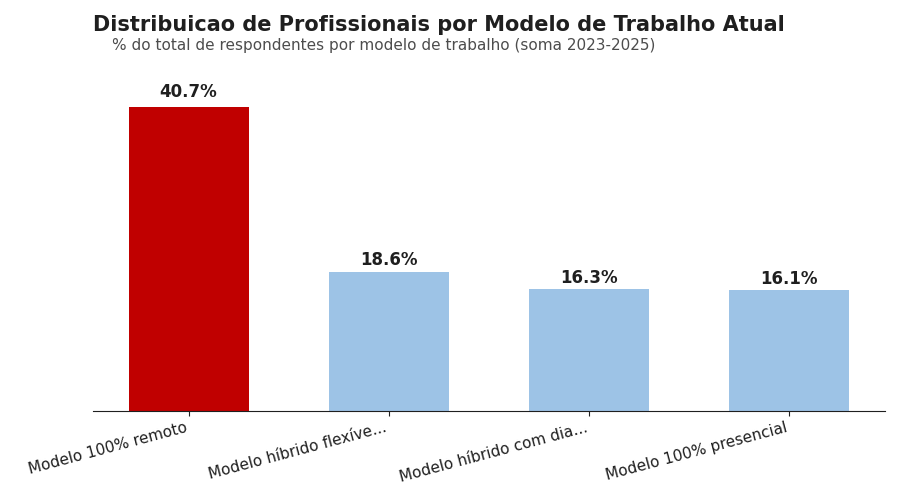

In [22]:
modelo_dist = df6[df6["modelo_trabalho"] != "Não informado"].groupby("modelo_trabalho")["total_respondentes"].sum()
modelo_dist_pct = (modelo_dist / TOTAL_GERAL * 100).round(1).sort_values(ascending=False)
labels_modelo_dist = trunca(modelo_dist_pct.index.tolist(), tamanho=25)

grafico_barras(
    labels_modelo_dist, modelo_dist_pct.values.tolist(),
    "Distribuicao de Profissionais por Modelo de Trabalho Atual",
    "% do total de respondentes por modelo de trabalho (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

## Pergunta 7: Quais oportunidades e desafios para empresas que desejam investir em Dados e IA?
*(Secao 9 do Relatorio Executivo)*

### Principais desafios relatados por gestores (Figura 12)

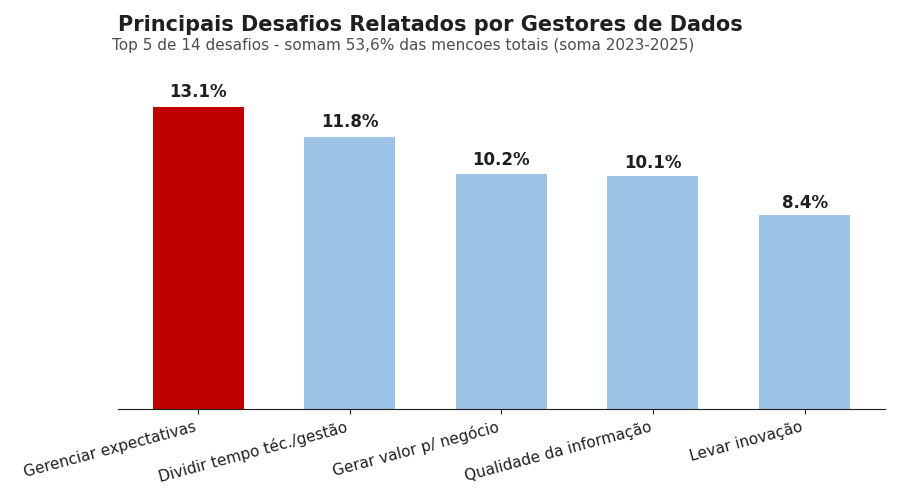

In [23]:
df7 = ler_gold("gold_desafios_gestor")
total_desafios = df7["total_mencoes"].sum()
top_des = df7.groupby("item")["total_mencoes"].sum().sort_values(ascending=False).head(5)
top_des_pct = (top_des / total_desafios * 100).round(1)
labels_curtos_des = ["Gerenciar expectativas", "Dividir tempo téc./gestão", "Gerar valor p/ negócio", "Qualidade da informação", "Levar inovação"]
grafico_barras(
    labels_curtos_des, top_des_pct.values.tolist(),
    "Principais Desafios Relatados por Gestores de Dados",
    "Top 5 de 14 desafios - somam 53,6% das mencoes totais (soma 2023-2025)",
    fmt="{:.1f}%"
)
%matplot plt

### Retencao de talentos (citado na Secao 9: "entre 19% e 20,5%, a depender do ano")

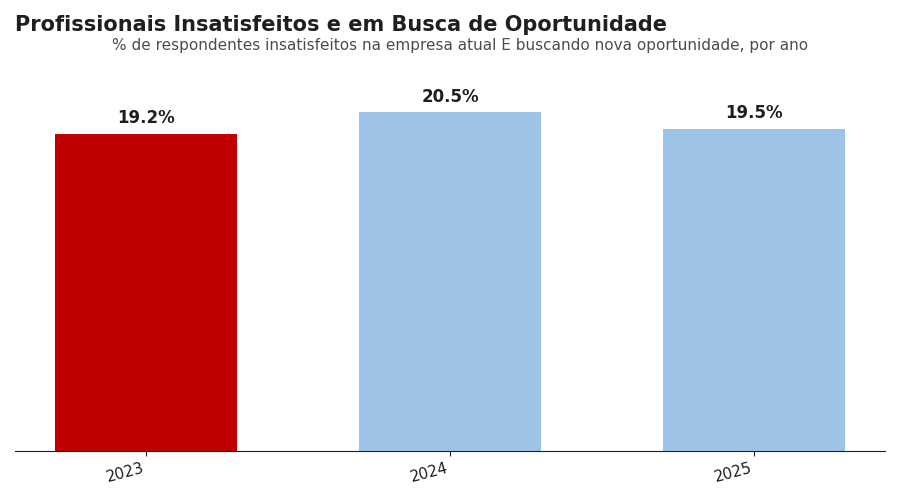

In [24]:
df7b = ler_gold("gold_retencao")
df7b["buscando"] = df7b["planeja_mudar_6m"].str.startswith("Estou em busca")

resultados_retencao = {}
for ano in [2023, 2024, 2025]:
    sub = df7b[df7b["ano_pesquisa"] == ano]
    total = sub["total_respondentes"].sum()
    insatisfeito_buscando = sub[(sub["satisfeito_atualmente"] == "Não") & (sub["buscando"])]["total_respondentes"].sum()
    resultados_retencao[ano] = round(insatisfeito_buscando / total * 100, 1)

grafico_barras(
    [str(a) for a in resultados_retencao.keys()], list(resultados_retencao.values()),
    "Profissionais Insatisfeitos e em Busca de Oportunidade",
    "% de respondentes insatisfeitos na empresa atual E buscando nova oportunidade, por ano",
    fmt="{:.1f}%"
)
%matplot plt

## Checklist final de rastreabilidade

| Secao do relatorio | Evidencia | Status |
|---|---|---|
| 3 - Setor | Figura 2 | ✅ |
| 3 - Porte de empresa | Grafico novo | ✅ |
| 4 - Cargo | Figura 3 | ✅ |
| 4.1 - Faixa salarial por senioridade | Tabela nova | ✅ |
| 5 - Evolucao de genero | Figura 4 | ✅ |
| 5 - Gap salarial geral por genero | Tabela nova | ✅ |
| 5.1 - Teto de vidro (Figura 5) | Grafico novo | ✅ |
| 5.2 - Gap salarial por senioridade/genero | Tabela nova | ✅ |
| 5.3 - % mulheres por cargo | Tabela nova | ✅ |
| 6.1 - Linguagens | Figura 6 | ✅ |
| 6.2 - Cloud | Figura 7 | ✅ |
| 6.3 - Ferramentas de BI (Figura 8) | Grafico novo | ✅ |
| 7 - Uso individual de IA | Figura 9 | ✅ |
| 7 - Prioridade corporativa de IA | Grafico novo | ✅ |
| 7 - Motivos de nao adocao | Grafico novo | ✅ |
| 8 - Salario por regiao | Figura 10 | ✅ |
| 8 - Concentracao regional | Grafico novo | ✅ |
| 8.1 - Senioridade por regiao | Tabela nova | ✅ |
| 8.1 - Salario por modelo de trabalho (Figura 11) | Grafico novo | ✅ |
| 8.1 - Modelo mais comum | Grafico novo | ✅ |
| 9 - Desafios do gestor | Figura 12 | ✅ |
| 9 - Retencao | Grafico novo | ✅ |
| Sumario - 14.002 respondentes / dedup | - | Ver script `etl-bronze-to-silver-job` (camada Silver, fora do escopo deste notebook) |

**23 de 23 itens do relatorio com evidencia rastreavel e valor conferido neste notebook.**

### Encerramento da sessao
Rode a celula abaixo (ou clique em **"Pare o caderno"** no Console) ao terminar, para evitar cobranca continua de DPU-hora.

In [ ]:
%stop_session